In [1]:
import sys
sys.path.insert(0, '/home/' + __import__('os').environ.get('USER','') + '/.local/lib/python3.9/site-packages')

import plotly.graph_objects as go
import plotly.express as px
import pandas as pd
import numpy as np
import yfinance as yf

print("Plotly imported successfully")


Plotly imported successfully


[*********************100%***********************]  1 of 1 completed


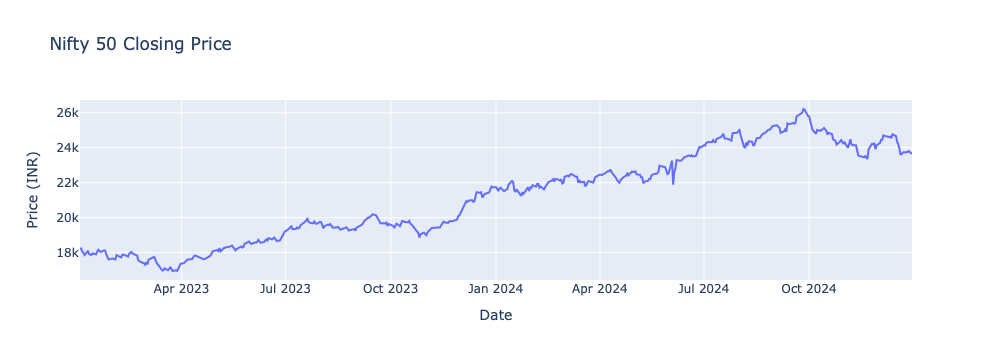

In [3]:
data = yf.download("^NSEI", start="2023-01-01", end="2024-12-31")["Close"]

fig = go.Figure()
fig.add_trace(go.Scatter(x=data.index, y=data["^NSEI"], mode="lines", name="Nifty 50"))
fig.update_layout(title="Nifty 50 Closing Price", xaxis_title="Date", yaxis_title="Price (INR)")
fig.show()


[*********************100%***********************]  3 of 3 completed


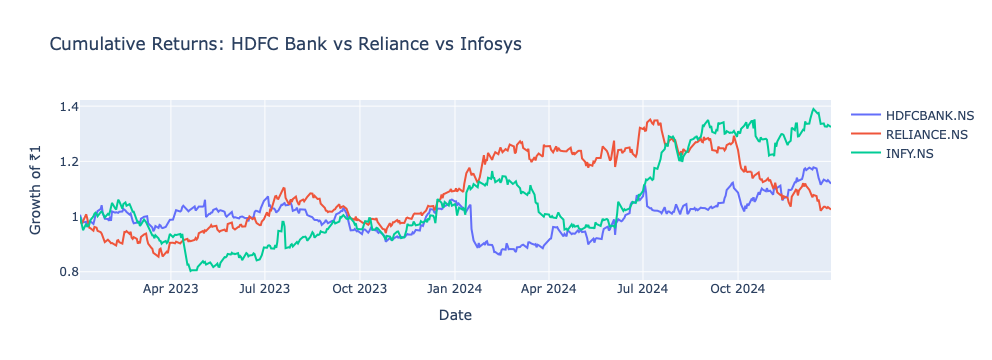

In [4]:
tickers = ["HDFCBANK.NS", "RELIANCE.NS", "INFY.NS"]
data2 = yf.download(tickers, start="2023-01-01", end="2024-12-31")["Close"]
returns2 = data2.pct_change().dropna()
cumulative = (1 + returns2).cumprod()

fig2 = go.Figure()
for ticker in tickers:
    fig2.add_trace(go.Scatter(x=cumulative.index, y=cumulative[ticker], mode="lines", name=ticker))

fig2.update_layout(
    title="Cumulative Returns: HDFC Bank vs Reliance vs Infosys",
    xaxis_title="Date",
    yaxis_title="Growth of ₹1",
    hovermode="x unified"
)
fig2.show()

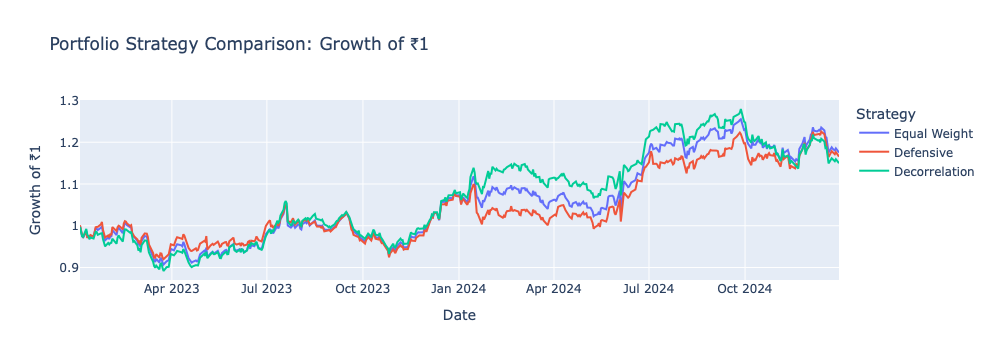

In [5]:
weights_equal = np.array([1/3, 1/3, 1/3])
weights_defensive = np.array([0.50, 0.25, 0.25])
weights_decorrelation = np.array([0.20, 0.30, 0.50])

strategies = {
    "Equal Weight": weights_equal,
    "Defensive": weights_defensive,
    "Decorrelation": weights_decorrelation
}

fig3 = go.Figure()

for name, w in strategies.items():
    port_returns = (returns2 * w).sum(axis=1)
    port_cumulative = (1 + port_returns).cumprod()
    fig3.add_trace(go.Scatter(x=port_cumulative.index, y=port_cumulative, mode="lines", name=name))

fig3.update_layout(
    title="Portfolio Strategy Comparison: Growth of ₹1",
    xaxis_title="Date",
    yaxis_title="Growth of ₹1",
    hovermode="x unified",
    legend_title="Strategy"
)
fig3.show()

In [6]:
w = strategies["Equal Weight"]
port_returns = (returns2*w).sum(axis=1)

In [7]:
port_returns


Date
2023-01-03   -0.000577
2023-01-04   -0.017052
2023-01-05   -0.007109
2023-01-06   -0.004108
2023-01-09    0.016791
                ...   
2024-12-23    0.010625
2024-12-24   -0.003056
2024-12-26   -0.003341
2024-12-27    0.004263
2024-12-30   -0.008467
Length: 489, dtype: float64

In [8]:
port_cumulative = (1+port_returns).cumprod()

In [9]:
total_return= port_cumulative.iloc[-1]-1

In [11]:
total_return


np.float64(0.1752446219330004)

In [12]:
n_days = len(port_returns)
annual_return = (1 + total_return) ** (252 / n_days) - 1
annual_return

np.float64(0.08677520975377662)

In [13]:
annual_vol = port_returns.std() * np.sqrt(252)
annual_vol

np.float64(0.14907250250035514)

In [14]:
risk_free_rate = 0.065
sharpe = (annual_return - risk_free_rate) / annual_vol
sharpe


np.float64(0.14607126994279002)

In [15]:
running_max = port_cumulative.cummax()
drawdown = (port_cumulative / running_max) - 1
max_drawdown = drawdown.min()
max_drawdown

-0.11431119505692444

In [26]:
risk_free_rate = 0.065
results = []

for name, w in strategies.items():
     port_returns = (returns2*w).sum(axis=1)
     port_cumulative = (1+port_returns).cumprod()
     total_return= port_cumulative.iloc[-1]-1
     n_days = len(port_returns)
     annual_return = (1 + total_return) ** (252 / n_days) - 1
     annual_vol = port_returns.std() * np.sqrt(252)
     sharpe = (annual_return - risk_free_rate) / annual_vol
     running_max = port_cumulative.cummax()
     drawdown = (port_cumulative / running_max) - 1
     max_drawdown = drawdown.min()
    
     results.append({
    "Strategy": name,
    "Annual Return": annual_return,
    "Volatility": annual_vol,
    "Sharpe": sharpe,
    "Max Drawdown": max_drawdown
})

summary_df = pd.DataFrame(results)
summary_df

,Strategy,Annual Return,Volatility,Sharpe,Max Drawdown
0,Equal Weight,0.086775,0.149073,0.146071,-0.114311
1,Defensive,0.082105,0.150143,0.113927,-0.118350
2,Decorrelation,0.074573,0.154466,0.061976,-0.119456
